In [4]:
from google.colab import files
import zipfile
import os
uploaded = files.upload()

Saving Sarcasm_Headlines_Dataset_v2.json to Sarcasm_Headlines_Dataset_v2.json


In [2]:
# Cell 1: Imports and Styling
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from wordcloud import WordCloud

# Download necessary NLTK data for lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')

# Set global aesthetic theme for pretty, presentable charts
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [5]:
# Cell 2: Load Data, Clean, Lemmatize, and Audit Setup
# Upload your kaggle json file using the Colab file widget if needed
# from google.colab import files; uploaded = files.upload()

df = pd.read_json('Sarcasm_Headlines_Dataset_v2.json', lines=True)

lemmatizer = WordNetLemmatizer()

def clean_and_lemmatize(text):
    # Remove punctuation and lowercase (your original logic)
    text = re.sub(r'[^\w\s]', '', text.lower())
    # Lemmatize each word
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)

# Apply preprocessing
df['clean'] = df['headline'].apply(clean_and_lemmatize)

# Subgroup feature for auditing text length
df['long'] = df['clean'].apply(lambda x: len(x.split()) >= 10)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['clean'], df['is_sarcastic'], test_size=0.2, random_state=42
)

In [6]:
# Cell 3: TF-IDF Vectorization and Training Multiple Models
vec = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, stop_words='english')
X_tr = vec.fit_transform(X_train)
X_te = vec.transform(X_test)

# Model 1: Logistic Regression (Your baseline)
log_model = LogisticRegression(C=1.5, max_iter=1000)
log_model.fit(X_tr, y_train)

# Model 2: Multinomial Naive Bayes (New comparison model)
nb_model = MultinomialNB()
nb_model.fit(X_tr, y_train)

# Predictions
y_pred_log = log_model.predict(X_te)
y_pred_nb = nb_model.predict(X_te)
probs_log = log_model.predict_proba(X_te)[:, 1]
probs_nb = nb_model.predict_proba(X_te)[:, 1]

In [7]:
# Cell 4: Performance Metrics and Fairness Audit
print("--- LOGISTIC REGRESSION OVERALL METRICS ---")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

print("\n--- NAIVE BAYES OVERALL METRICS ---")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

print("\n--- SUBGROUP AUDIT (LOGISTIC REGRESSION) ---")
# Masks for long and short text
mask_short = ~df.loc[X_test.index, 'long']
mask_long = df.loc[X_test.index, 'long']

print("Short Acc (<10 words):", accuracy_score(y_test[mask_short], y_pred_log[mask_short]))
print("Long Acc (>=10 words):", accuracy_score(y_test[mask_long], y_pred_log[mask_long]))

--- LOGISTIC REGRESSION OVERALL METRICS ---
Accuracy: 0.7933263452131377
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      2995
           1       0.80      0.76      0.78      2729

    accuracy                           0.79      5724
   macro avg       0.79      0.79      0.79      5724
weighted avg       0.79      0.79      0.79      5724


--- NAIVE BAYES OVERALL METRICS ---
Accuracy: 0.8038085255066387
              precision    recall  f1-score   support

           0       0.80      0.83      0.82      2995
           1       0.81      0.77      0.79      2729

    accuracy                           0.80      5724
   macro avg       0.80      0.80      0.80      5724
weighted avg       0.80      0.80      0.80      5724


--- SUBGROUP AUDIT (LOGISTIC REGRESSION) ---
Short Acc (<10 words): 0.7719705768486256
Long Acc (>=10 words): 0.8108882521489972


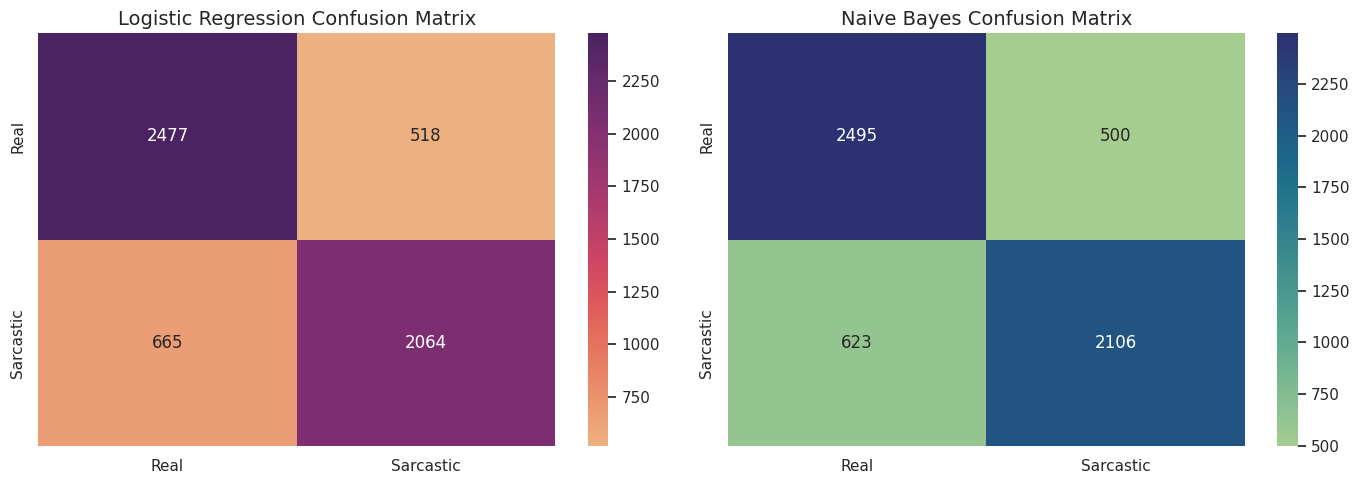

In [8]:
# Cell 5: Visualizing Confusion Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='flare',
            xticklabels=['Real', 'Sarcastic'], yticklabels=['Real', 'Sarcastic'], ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')

sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='crest',
            xticklabels=['Real', 'Sarcastic'], yticklabels=['Real', 'Sarcastic'], ax=axes[1])
axes[1].set_title('Naive Bayes Confusion Matrix')

plt.tight_layout()
plt.show()

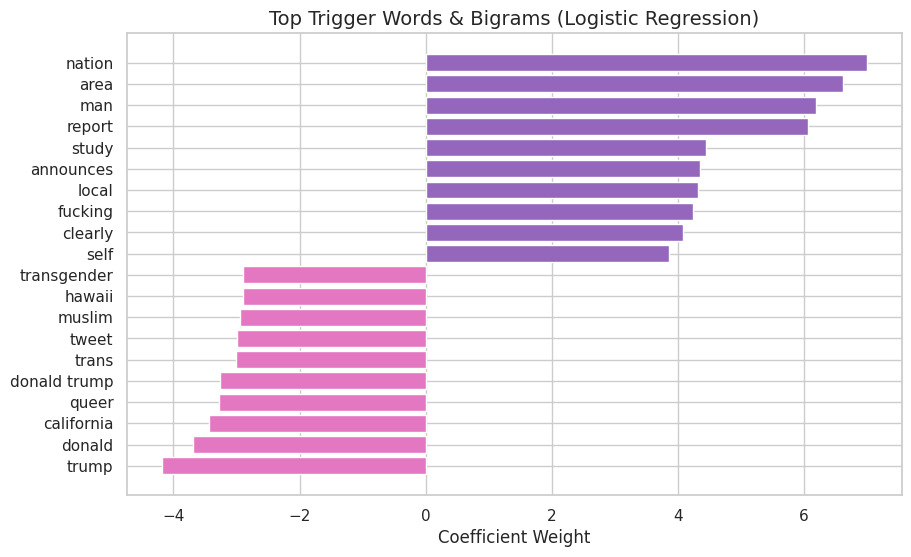

In [14]:
# Cell 6: Feature Importance for Logistic Regression
feats = np.array(vec.get_feature_names_out())
coefs = log_model.coef_[0]
idx = np.argsort(coefs)

# Top 10 negative (Real) and top 10 positive (Sarcastic)
top_w = np.concatenate([feats[idx[:10]], feats[idx[-10:]]])
top_s = np.concatenate([coefs[idx[:10]], coefs[idx[-10:]]])

plt.figure(figsize=(10, 6))
# Using a clean custom palette for the bars
colors = ['#e377c2' if s < 0 else '#9467bd' for s in top_s]
plt.barh(top_w, top_s, color=colors)
plt.title('Top Trigger Words & Bigrams (Logistic Regression)')
plt.xlabel('Coefficient Weight')
plt.show()

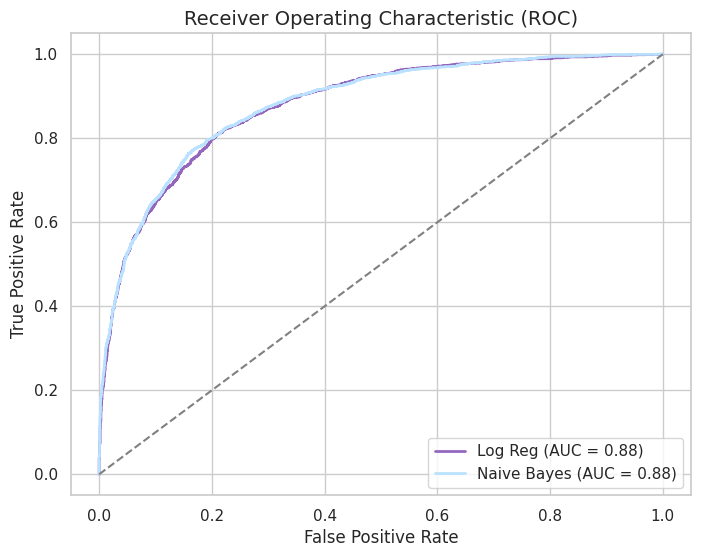

In [16]:
# Cell 7: ROC Curve comparing both models
fpr_log, tpr_log, _ = roc_curve(y_test, probs_log)
fpr_nb, tpr_nb, _ = roc_curve(y_test, probs_nb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, color='#9467bd', lw=2, label=f'Log Reg (AUC = {auc(fpr_log, tpr_log):.2f})')
plt.plot(fpr_nb, tpr_nb, color='#bae1ff', lw=2, label=f'Naive Bayes (AUC = {auc(fpr_nb, tpr_nb):.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

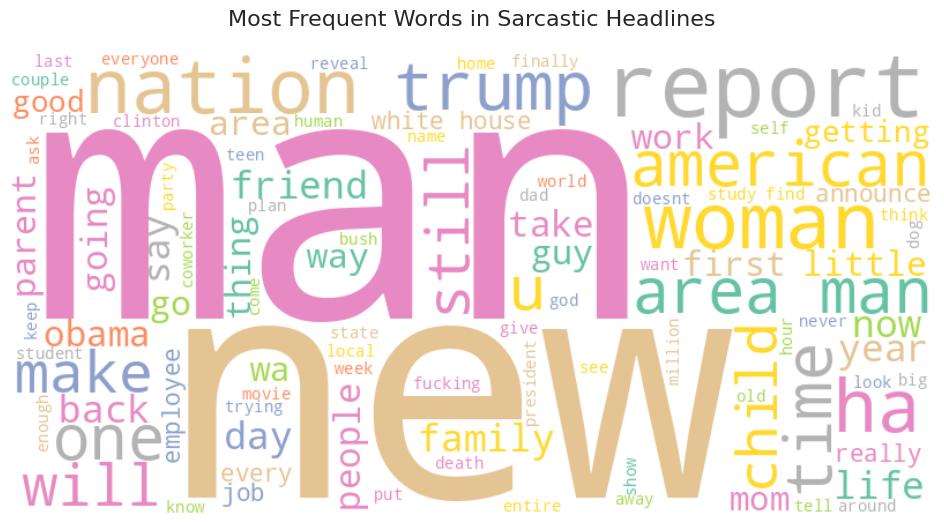

In [12]:
# Cell 8: Aesthetic Word Cloud for Sarcastic Headlines
sarcastic_text = " ".join(df[df['is_sarcastic'] == 1]['clean'])

wc = WordCloud(width=800, height=400, max_words=100,
               background_color='white', colormap='Set2').generate(sarcastic_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Sarcastic Headlines', fontsize=16, pad=20)
plt.show()